## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_nuts3_gdf = gpd.read_file(f"{folder_path}/elladitsa_nomoi.shp",  encoding=dec)
greece_nuts2_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
greece_rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((385995.813 4480598.500, 385855..."
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((444114.046 4201703.450, 444095..."
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((234505.297 4469743.499, 234459.375 4..."
3,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((350911.406 4558247.998, 350936.187 4..."
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((296728.718 4346288.000, 296808.656 4..."


In [8]:
greece_nuts2_gdf

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."
5,Π. ΒΟΡΕΙΟΥ ΑΙΓΑΙΟΥ,"MULTIPOLYGON (((24.97064 39.50330, 24.97071 39..."
6,Π. ΝΟΤΙΟΥ ΑΙΓΑΙΟΥ,"MULTIPOLYGON (((24.12909 36.50774, 24.12909 36..."
7,Π. ΣΤΕΡΕΑΣ ΕΛΛΑΔΑΣ,"MULTIPOLYGON (((21.37464 39.01890, 21.37471 39..."
8,Π. ΔΥΤΙΚΗΣ ΕΛΛΑΔΑΣ,"MULTIPOLYGON (((21.10483 37.85062, 21.10511 37..."
9,Π. ΠΕΛΟΠΟΝΝΗΣΟΥ,"MULTIPOLYGON (((21.53886 37.05523, 21.53886 37..."


In [9]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')
print(f'greece_rivers CRS: {greece_rivers_gdf.crs}')

greece_nuts3 CRS: epsg:2100
greece_nuts2 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
greece_rivers CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [10]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_rivers_gdf = greece_rivers_gdf.to_crs(epsg=4326)

In [11]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')
print(f'greece_rivers CRS: {greece_rivers_gdf.crs}')

greece_nuts3 CRS: epsg:4326
greece_nuts2 CRS: epsg:4326
greece_rivers CRS: epsg:4326


In [12]:
greece_nuts3_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry
0,61000000,61000000,Ν. ΠΙΕΡΙΑΣ,N. PIERIAS,126412,ΚΑΤΕΡΙΝΗ,273982.673303,1.521683e+09,"MULTIPOLYGON (((22.65694 40.47085, 22.65532 40..."
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37..."
2,33000000,33000000,Ν. ΙΩΑΝΝΙΝΩΝ,N. IOANNINON,161027,ΙΩΑΝΝΙΝΑ,459160.764413,4.999038e+09,"POLYGON ((20.87623 40.33865, 20.87576 40.33726..."
3,59000000,59000000,Ν. ΠΕΛΛΑΣ,N. PELLAS,143957,ΕΔΕΣΣΑ,323924.955195,2.505800e+09,"POLYGON ((22.22469 41.16447, 22.22498 41.16444..."
4,05000000,05000000,Ν. ΕΥΡΥΤΑΝΙΑΣ,N. EVRYTANIAS,19518,ΚΑΡΠΕΝΗΣΙ,267851.316606,1.870664e+09,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."


In [13]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 55


In [14]:
greece_nuts2_gdf.head(5)

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [15]:
print(f'Length of greece_nuts2_gdf: {len(greece_nuts2_gdf)}')

Length of greece_nuts2_gdf: 13


In [16]:
#choose the correct region

region = greece_nuts2_gdf.loc[greece_nuts2_gdf['PER'] == 'Π. ΑΤΤΙΚΗΣ'].copy()
region.head()

,PER,geometry
12,Π. ΑΤΤΙΚΗΣ,"MULTIPOLYGON (((22.89876 36.19485, 22.89888 36..."


In [17]:
print(f'region CRS: {region.crs}')

region CRS: epsg:4326


In [18]:
nuts2_gdf = gpd.sjoin(greece_nuts3_gdf, region, how = 'inner', op='intersects')

In [19]:
nuts2_gdf.head()

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry,index_right,PER
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37...",12,Π. ΑΤΤΙΚΗΣ
12,96000000,96000000,Ν. ΠΕΙΡΑΙΩΣ ΚΑΙ ΝΗΣΩΝ,N. PIREOS KE NISON,553450,ΠΕΙΡΑΙΑΣ,733521.804576,9.291890e+08,"MULTIPOLYGON (((23.30317 35.89263, 23.30308 35...",12,Π. ΑΤΤΙΚΗΣ
24,99000000,99000000,Ν. ΑΘΗΝΩΝ,N. ATHINON,2805262,ΑΘΗΝΑ,133572.782478,3.593008e+08,"POLYGON ((23.85782 38.11577, 23.85843 38.11488...",12,Π. ΑΤΤΙΚΗΣ
25,98000000,98000000,Ν. ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ,N. ANATOLIKIS ATTIKIS,386067,ΠΑΛΛΗΝΗ,378795.509994,1.518329e+09,"MULTIPOLYGON (((23.94439 37.46075, 23.94374 37...",12,Π. ΑΤΤΙΚΗΣ
28,15000000,15000000,Ν. ΚΟΡΙΝΘΟΥ,N. KORINTHOU,144527,ΚΟΡΙΝΘΟΣ,387829.582098,2.290212e+09,"MULTIPOLYGON (((23.17484 37.76003, 23.17399 37...",12,Π. ΑΤΤΙΚΗΣ


<AxesSubplot:>

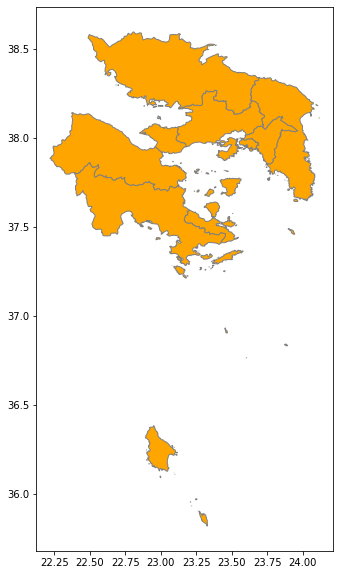

In [20]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [21]:
nuts2_gdf.NAME_GR.unique()

array(['Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ', 'Ν. ΠΕΙΡΑΙΩΣ ΚΑΙ ΝΗΣΩΝ', 'Ν. ΑΘΗΝΩΝ',
       'Ν. ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ', 'Ν. ΚΟΡΙΝΘΟΥ', 'Ν. ΒΟΙΩΤΙΑΣ',
       'Ν. ΑΡΓΟΛΙΔΑΣ'], dtype=object)

In [27]:
#check QGIS for wrong lau1 units

In [22]:
wrong_list = ['Ν. ΚΟΡΙΝΘΟΥ', 'Ν. ΒΟΙΩΤΙΑΣ','Ν. ΑΡΓΟΛΙΔΑΣ']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME_GR'].isin(wrong_list)].copy()

In [23]:
nuts2_gdf.head(5)

,PARENT,ESYE_ID,NAME_GR,NAME_ENG,POP,EDRA,SHAPE_LENG,SHAPE_AREA,geometry,index_right,PER
1,97000000,97000000,Ν. ΔΥΤΙΚΗΣ ΑΤΤΙΚΗΣ,N. DYTIKIS ATTIKIS,149794,ΕΛΕΥΣΙΝΑ,226024.536125,1.004945e+09,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37...",12,Π. ΑΤΤΙΚΗΣ
12,96000000,96000000,Ν. ΠΕΙΡΑΙΩΣ ΚΑΙ ΝΗΣΩΝ,N. PIREOS KE NISON,553450,ΠΕΙΡΑΙΑΣ,733521.804576,9.291890e+08,"MULTIPOLYGON (((23.30317 35.89263, 23.30308 35...",12,Π. ΑΤΤΙΚΗΣ
24,99000000,99000000,Ν. ΑΘΗΝΩΝ,N. ATHINON,2805262,ΑΘΗΝΑ,133572.782478,3.593008e+08,"POLYGON ((23.85782 38.11577, 23.85843 38.11488...",12,Π. ΑΤΤΙΚΗΣ
25,98000000,98000000,Ν. ΑΝΑΤΟΛΙΚΗΣ ΑΤΤΙΚΗΣ,N. ANATOLIKIS ATTIKIS,386067,ΠΑΛΛΗΝΗ,378795.509994,1.518329e+09,"MULTIPOLYGON (((23.94439 37.46075, 23.94374 37...",12,Π. ΑΤΤΙΚΗΣ


In [24]:
nuts2_gdf.drop(columns=['PARENT', 'ESYE_ID', 'NAME_ENG', 'POP', 'EDRA', 'SHAPE_LENG', 'SHAPE_AREA'], inplace = True)
nuts2_gdf.rename(columns={"NAME_GR": "nuts3"}, inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'nuts3')

In [25]:
nuts2_gdf.head(5)

,nuts3,geometry,index_right,PER
0,δυτικης αττικης,"MULTIPOLYGON (((23.36549 37.96383, 23.36527 37...",12,Π. ΑΤΤΙΚΗΣ
1,πειραιως και νησων,"MULTIPOLYGON (((23.30317 35.89263, 23.30308 35...",12,Π. ΑΤΤΙΚΗΣ
2,αθηνων,"POLYGON ((23.85782 38.11577, 23.85843 38.11488...",12,Π. ΑΤΤΙΚΗΣ
3,ανατολικης αττικης,"MULTIPOLYGON (((23.94439 37.46075, 23.94374 37...",12,Π. ΑΤΤΙΚΗΣ


<AxesSubplot:>

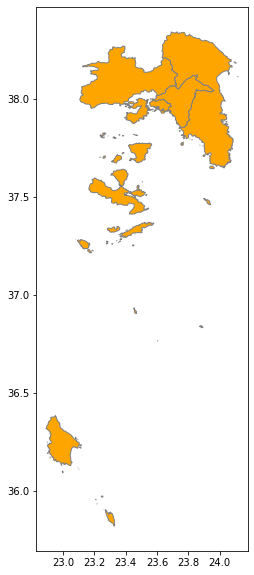

In [26]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [27]:
nuts2_rivers_gdf = gpd.sjoin(greece_rivers_gdf, region, how = 'inner', op='intersects')

In [28]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry,index_right,PER
8,9,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,2499.061150,"LINESTRING (24.02301 38.15953, 24.02301 38.159...",12,Π. ΑΤΤΙΚΗΣ
11,12,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,3917.094155,"LINESTRING (23.82103 38.07738, 23.81889 38.077...",12,Π. ΑΤΤΙΚΗΣ
22,25,None,ÊÑÕÖÔÇ Ñ.,KRYFTH R.,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,4186.529821,"LINESTRING (23.31597 38.08893, 23.31597 38.088...",12,Π. ΑΤΤΙΚΗΣ
33,38,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,1069.313080,"LINESTRING (23.70861 37.92394, 23.70805 37.923...",12,Π. ΑΤΤΙΚΗΣ
40,48,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,0.0,0.0,0.0,no,3884.708691,"LINESTRING (23.48943 38.04971, 23.49014 38.050...",12,Π. ΑΤΤΙΚΗΣ


<AxesSubplot:>

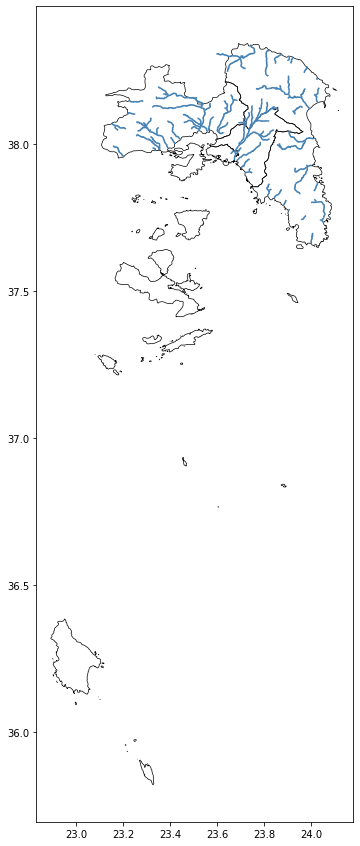

In [29]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [30]:
nuts3_units = nuts2_gdf['nuts3'].unique().tolist()

if not os.path.exists(f'../../data/{NUTS2}/'):
    os.makedirs(f'../../data/{NUTS2}/')

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_NUTS3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_units:
        f.write("%s\n" % item)

print(f"Number of NUTS3 Units in {NUTS2} (from shapefile): {len(nuts3_units)}")

Number of NUTS3 Units in Attica (from shapefile): 4


In [31]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [50]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='nuts3', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [51]:
df_grid.rename(columns={"NAME": "nuts3"}, inplace = True)

<AxesSubplot:>

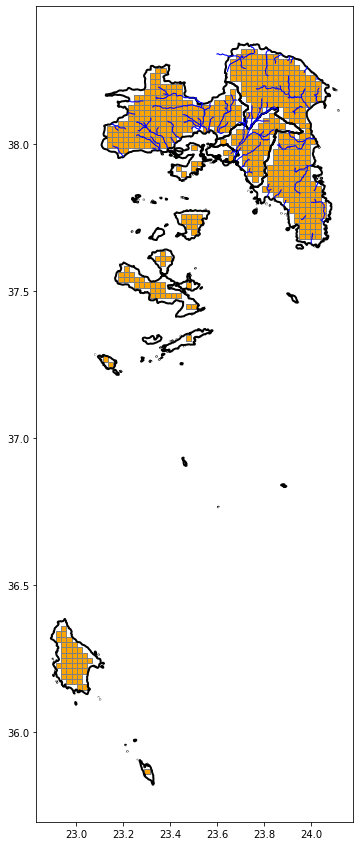

In [52]:
ax = nuts2_rivers_gdf.plot(figsize=(15, 15), cmap='jet', color='blue', lw=1)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [53]:
grid_nuts3 = df_grid['nuts3'].unique().tolist()
print(f"Number of NUTS3 Units in Grid: {len(grid_nuts3)}")

Number of NUTS3 Units in Grid: 4


In [54]:
if (len(nuts3_units) != len(grid_nuts3)):
    delta = [item for item in nuts3_units if item not in grid_nuts3]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['nuts3'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['nuts3'] = lost_lau1['nuts3']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [55]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [56]:
nuts2_grid

,geometry,nuts3,x,y
0,"POLYGON ((23.15226 37.98748, 23.15226 38.00545...",δυτικης αττικης,23.14086,37.99647
1,"POLYGON ((23.15226 38.00545, 23.15226 38.02342...",δυτικης αττικης,23.14086,38.01443
2,"POLYGON ((23.15226 38.02342, 23.15226 38.04138...",δυτικης αττικης,23.14086,38.03240
3,"POLYGON ((23.15226 38.04138, 23.15226 38.05935...",δυτικης αττικης,23.14086,38.05037
4,"POLYGON ((23.17504 37.98748, 23.17504 38.00545...",δυτικης αττικης,23.16365,37.99647
...,...,...,...,...
633,"POLYGON ((24.03955 38.17896, 24.03955 38.19693...",ανατολικης αττικης,24.02824,38.18795
634,"POLYGON ((24.03955 38.19693, 24.03955 38.21490...",ανατολικης αττικης,24.02824,38.20591
635,"POLYGON ((24.06219 37.74776, 24.06219 37.76573...",ανατολικης αττικης,24.05087,37.75675
636,"POLYGON ((24.06219 37.76573, 24.06219 37.78370...",ανατολικης αττικης,24.05087,37.77471


In [57]:
if (len(nuts3_units) != len(grid_nuts3)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [58]:
nuts2_grid['nuts2'] = NUTS2_EL

In [59]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [60]:
nuts2_grid

,shape,nuts3,x,y,nuts2
0,"POLYGON ((23.15226 37.98748, 23.15226 38.00545...",δυτικης αττικης,23.14086,37.99647,αττικης
1,"POLYGON ((23.15226 38.00545, 23.15226 38.02342...",δυτικης αττικης,23.14086,38.01443,αττικης
2,"POLYGON ((23.15226 38.02342, 23.15226 38.04138...",δυτικης αττικης,23.14086,38.03240,αττικης
3,"POLYGON ((23.15226 38.04138, 23.15226 38.05935...",δυτικης αττικης,23.14086,38.05037,αττικης
4,"POLYGON ((23.17504 37.98748, 23.17504 38.00545...",δυτικης αττικης,23.16365,37.99647,αττικης
...,...,...,...,...,...
633,"POLYGON ((24.03955 38.17896, 24.03955 38.19693...",ανατολικης αττικης,24.02824,38.18795,αττικης
634,"POLYGON ((24.03955 38.19693, 24.03955 38.21490...",ανατολικης αττικης,24.02824,38.20591,αττικης
635,"POLYGON ((24.06219 37.74776, 24.06219 37.76573...",ανατολικης αττικης,24.05087,37.75675,αττικης
636,"POLYGON ((24.06219 37.76573, 24.06219 37.78370...",ανατολικης αττικης,24.05087,37.77471,αττικης


In [61]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [62]:
nuts2_grid_points

,shape,nuts3,x,y,nuts2,geometry
0,"POLYGON ((23.15226 37.98748, 23.15226 38.00545...",δυτικης αττικης,23.14086,37.99647,αττικης,POINT (23.14086 37.99647)
1,"POLYGON ((23.15226 38.00545, 23.15226 38.02342...",δυτικης αττικης,23.14086,38.01443,αττικης,POINT (23.14086 38.01443)
2,"POLYGON ((23.15226 38.02342, 23.15226 38.04138...",δυτικης αττικης,23.14086,38.03240,αττικης,POINT (23.14086 38.03240)
3,"POLYGON ((23.15226 38.04138, 23.15226 38.05935...",δυτικης αττικης,23.14086,38.05037,αττικης,POINT (23.14086 38.05037)
4,"POLYGON ((23.17504 37.98748, 23.17504 38.00545...",δυτικης αττικης,23.16365,37.99647,αττικης,POINT (23.16365 37.99647)
...,...,...,...,...,...,...
633,"POLYGON ((24.03955 38.17896, 24.03955 38.19693...",ανατολικης αττικης,24.02824,38.18795,αττικης,POINT (24.02824 38.18795)
634,"POLYGON ((24.03955 38.19693, 24.03955 38.21490...",ανατολικης αττικης,24.02824,38.20591,αττικης,POINT (24.02824 38.20591)
635,"POLYGON ((24.06219 37.74776, 24.06219 37.76573...",ανατολικης αττικης,24.05087,37.75675,αττικης,POINT (24.05087 37.75675)
636,"POLYGON ((24.06219 37.76573, 24.06219 37.78370...",ανατολικης αττικης,24.05087,37.77471,αττικης,POINT (24.05087 37.77471)


<AxesSubplot:>

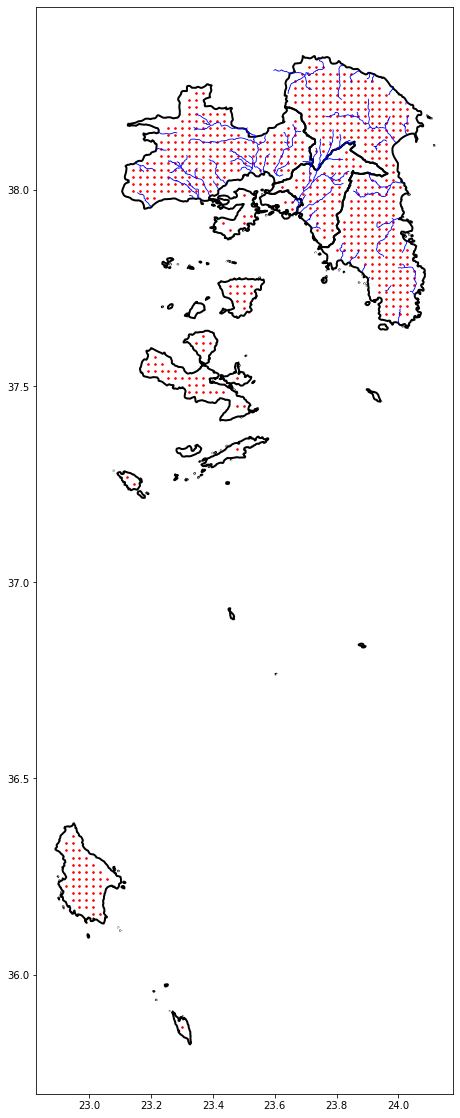

In [63]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=0.8)

In [64]:
final_grid = nuts2_grid[['nuts2', 'nuts3', 'x', 'y']].sort_values(by=['nuts3'])
final_grid.reset_index(drop = True, inplace= True)

In [65]:
final_grid

,nuts2,nuts3,x,y
0,αττικης,αθηνων,23.76093,37.95263
1,αττικης,αθηνων,23.73818,38.02449
2,αττικης,αθηνων,23.73818,38.00653
3,αττικης,αθηνων,23.73818,37.98856
4,αττικης,αθηνων,23.73818,37.97059
...,...,...,...,...
633,αττικης,πειραιως και νησων,22.99052,36.28063
634,αττικης,πειραιως και νησων,22.99052,36.24469
635,αττικης,πειραιως και νησων,22.99052,36.22673
636,αττικης,πειραιως και νησων,23.01268,36.26266


In [66]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid_NUTS3.csv', encoding=enc, index = False)